# Plots of the clusters trialled in the work

## Imports

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astroquery.hips2fits import hips2fits
from astroquery.simbad import Simbad
import astropy.units as u
from astropy.coordinates import Longitude, Latitude, Angle, SkyCoord
from astropy.wcs import WCS
from gaianir_open_clusters import plots

plots.setup_matplotlib(no_log=True)

# Suppress numpy warnings
_ = np.seterr(all="ignore")

## Images of the real ones

In [7]:
def download_image(
    catalogue="CDS/P/DSS2/color",
    width=1000,
    height=1000,
    ra=260.664468,
    dec=-23.8318557,
    fov=0.2,
    projection="TAN",
    coordsys="galactic",
    name=None,
):
    if isinstance(name, str):
        print("Looking up object on Simbad...")
        simbad_result = Simbad.query_object(name)
        if len(simbad_result) == 0:
            raise ValueError(
                f"Unable to find region {name} on Simbad database. Is your spelling "
                "correct?"
            )
        ra = simbad_result["ra"].to(u.deg).value[0]
        dec = simbad_result["dec"].to(u.deg).value[0]

    print("Downloading data...")
    result = hips2fits.query(
        hips=catalogue,
        width=width,
        height=height,
        ra=Longitude(ra * u.deg),
        dec=Latitude(dec * u.deg),
        fov=Angle(fov * u.deg),
        projection=projection,
        coordsys=coordsys,
    )[0]

    # Create coordinate system
    wcs = WCS(result.header).celestial

    # Transpose array if it has a color channel
    data = result.data
    if len(data.shape) > 2:
        data = np.transpose(result.data[:-1], (1, 2, 0))

    return data, wcs

In [27]:
pleiades_image = download_image(name="Pleiades", fov=3)

rcw_36_image = download_image(ra=134.865016, dec=-43.7572148, fov=0.2)

berkeley_29_image = download_image(name="Berkeley 29", fov=0.1)

Looking up object on Simbad...
Looking up object on Simbad...


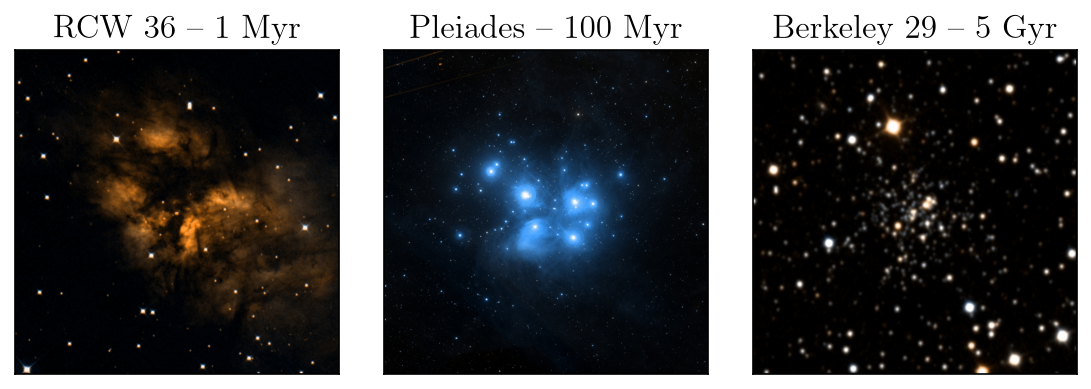

In [46]:
# fig = plt.figure(figsize=(plots.TEXTWIDTH, plots.COLWIDTH))

# ax = [
#     fig.add_subplot(1, 3, 1, projection=pleiades_image[1]),
#     fig.add_subplot(1, 3, 2, projection=rcw_36_image[1]),
#     fig.add_subplot(1, 3, 3, projection=berkeley_29_image[1]),
# ]

fig, ax = plt.subplots(ncols=3, figsize=(plots.TEXTWIDTH, plots.COLWIDTH * 0.7))

ax[0].imshow(rcw_36_image[0], origin="lower", cmap="grey")
ax[1].imshow(pleiades_image[0], origin="lower", cmap="grey")
ax[2].imshow(berkeley_29_image[0], origin="lower", cmap="grey")

for an_ax in ax:
    an_ax.set(xticks=[], yticks=[])

# to add spacing (cheeky hack)
ax[1].set(ylabel=" ")
ax[2].set(ylabel=" ")

ax[0].set_title("RCW 36 -- 1 Myr", fontsize=16)
ax[1].set_title("Pleiades -- 100 Myr", fontsize=16)
ax[2].set_title("Berkeley 29 -- 5 Gyr", fontsize=16)

fig.savefig(plots.FIGS_PRES / "clusters.png")